In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
path = "/content/gdrive/MyDrive/Praktikum/Praktikum06/data"

In [5]:
df = pd.read_csv(path + '/gempa.csv')
df.head()

,magnitude,depth,cdi,mmi,sig,alert
0,7.0,14.0,8.0,7.0,0.0,green
1,6.9,25.0,4.0,4.0,-33.0,green
2,7.0,579.0,3.0,3.0,-13.0,green
3,7.3,37.0,5.0,5.0,65.0,green
4,6.6,624.0,0.0,2.0,-98.0,green


In [6]:
df.describe()

,magnitude,depth,cdi,mmi,sig
count,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000
mean,7.061008,50.321538,6.976154,6.939231,-9.749231
std,0.423738,104.348286,2.244875,1.354774,62.245214
min,6.500000,2.000000,0.000000,1.000000,-128.000000
25%,6.700000,12.000000,6.000000,6.000000,-54.000000
50%,7.000000,19.000000,8.000000,7.000000,-7.000000
75%,7.300000,38.000000,8.000000,8.000000,31.000000
max,8.600000,670.000000,9.000000,9.000000,127.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   magnitude  1300 non-null   float64
 1   depth      1300 non-null   float64
 2   cdi        1300 non-null   float64
 3   mmi        1300 non-null   float64
 4   sig        1300 non-null   float64
 5   alert      1300 non-null   object 
dtypes: float64(5), object(1)
memory usage: 61.1+ KB


In [50]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
X = df[['magnitude', 'depth', 'cdi', 'mmi','sig']]
y = df['alert']
le = LabelEncoder()
y_encoded = le.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [51]:
X.head()

,magnitude,depth,cdi,mmi,sig
0,7.0,14.0,8.0,7.0,0.0
1,6.9,25.0,4.0,4.0,-33.0
2,7.0,579.0,3.0,3.0,-13.0
3,7.3,37.0,5.0,5.0,65.0
4,6.6,624.0,0.0,2.0,-98.0


In [52]:
y.head()

,alert
0,green
1,green
2,green
3,green
4,green


In [99]:
model = SVC(kernel='rbf', )
model.fit(X_train_scaled, y_train)

SVC()

In [100]:
y_pred = model.predict(X_test_scaled)

print(f"Akurasi : {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nLaporan Klasifikasi :", classification_report(y_test, y_pred))

Akurasi : 79.23%

Laporan Klasifikasi :               precision    recall  f1-score   support

           0       0.90      0.81      0.85        68
           1       0.80      0.64      0.71        73
           2       0.69      0.95      0.80        64
           3       0.83      0.78      0.80        55

    accuracy                           0.79       260
   macro avg       0.80      0.80      0.79       260
weighted avg       0.81      0.79      0.79       260



In [92]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns


Confusion Matrix
 [[55  7  0  6]
 [ 0 47 23  3]
 [ 0  3 61  0]
 [ 6  2  4 43]]


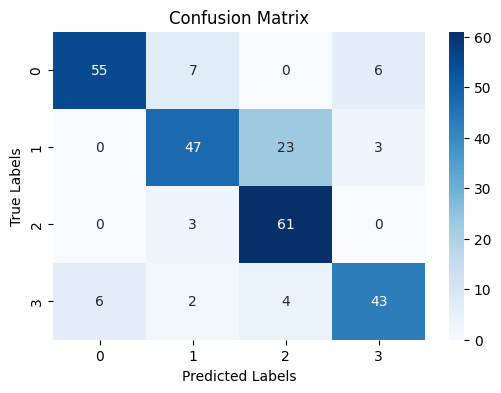

In [93]:
print("\nConfusion Matrix\n",confusion_matrix(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

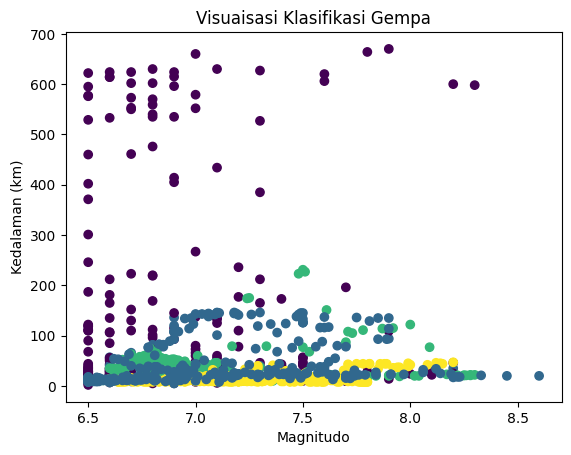

In [106]:
plt.scatter(df['magnitude'], df['depth'], c=df['alert'].astype('category').cat.codes,)
plt.xlabel('Magnitudo')
plt.ylabel('Kedalaman (km)')
plt.title('Visuaisasi Klasifikasi Gempa')
plt.show()

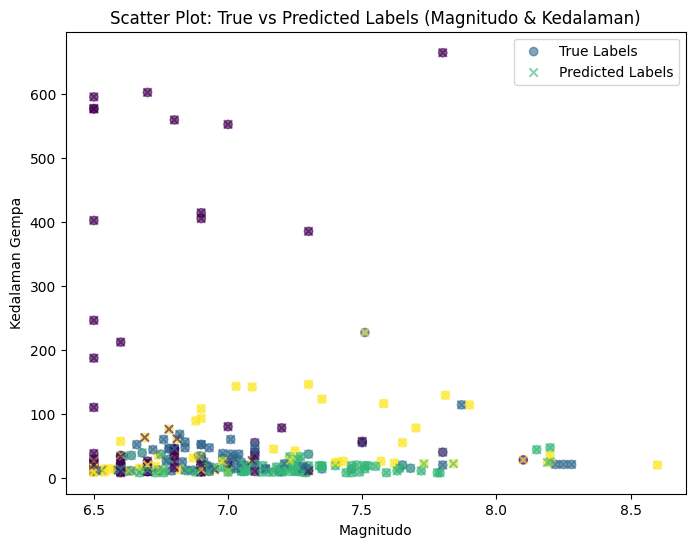

In [107]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_test_encoded = le.fit_transform(y_test)
y_pred_encoded = le.transform(y_pred)

plt.figure(figsize=(8, 6))

plt.scatter(X_test['magnitude'], X_test['depth'], c=y_test_encoded, cmap='viridis', marker='o', label='True Labels', alpha=0.6)

plt.scatter(X_test['magnitude'], X_test['depth'], c=y_pred_encoded, cmap='viridis', marker='x', label='Predicted Labels', alpha=0.6)

plt.title('Scatter Plot: True vs Predicted Labels (Magnitudo & Kedalaman)')
plt.xlabel('Magnitudo')
plt.ylabel('Kedalaman Gempa')
plt.legend()
plt.show()

In [80]:
df['alert'].unique()

['green', 'yellow', 'orange', 'red']
Categories (4, object): ['green', 'orange', 'red', 'yellow']

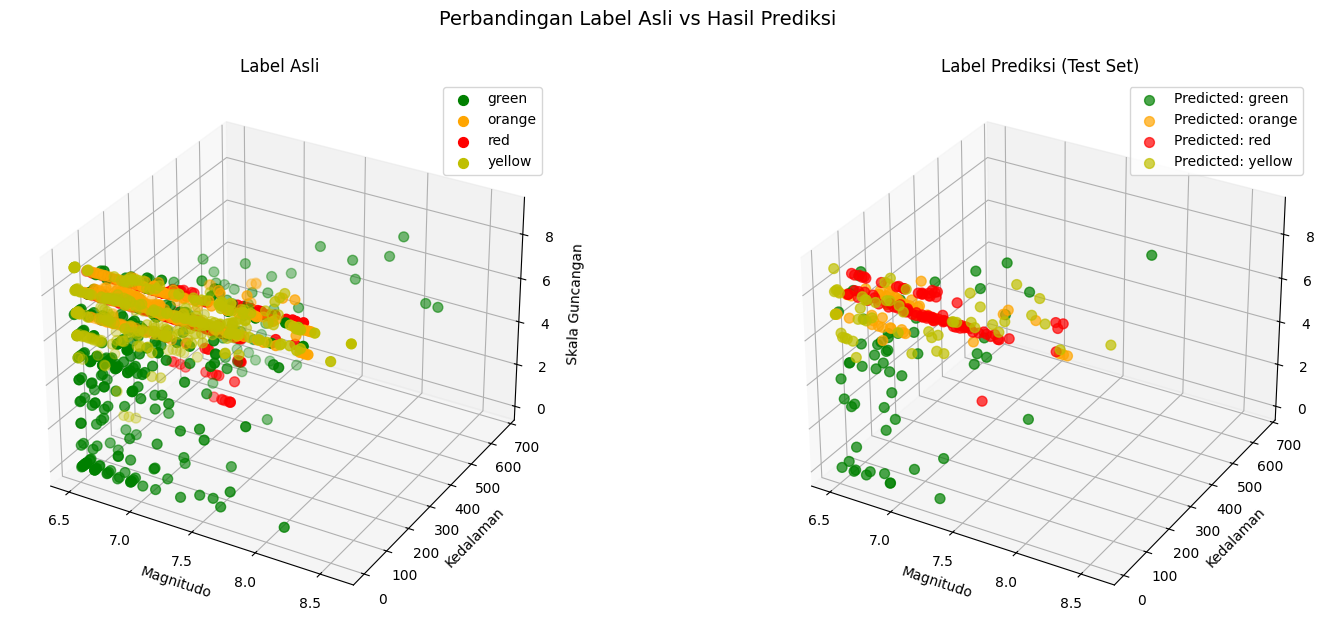

In [89]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

le = LabelEncoder()
df['alertEncoded'] = le.fit_transform(df['alert'])

colors = ['g', 'orange', 'r', 'y']
labels = le.classes_


fig = plt.figure(figsize=(18, 7))

# Plot 1: Label Asli
ax1 = fig.add_subplot(121, projection='3d')
for i, alert in enumerate(labels):
    subset = df[df['alertEncoded'] == i]
    ax1.scatter(
        subset['magnitude'],
        subset['depth'],
        subset['cdi'],
        color=colors[i],
        label=alert,
        s=50
    )
ax1.set_title('Label Asli')
ax1.set_xlabel('Magnitudo')
ax1.set_ylabel('Kedalaman')
ax1.set_zlabel('Skala Guncangan')
ax1.legend()

ax2 = fig.add_subplot(122, projection='3d')
df['Predicted'] = None
df.loc[X_test.index, 'Predicted'] = y_pred



plot_column = 'Predicted'
df['PredictedLabel'] = np.nan
df['PredictedLabel'] = df['alert'].astype(str)
df.loc[X_test.index, 'PredictedLabel'] = le.inverse_transform(
    df.loc[X_test.index, plot_column].astype(int)
)



for i, alert_label in enumerate(labels):
    subset = df.loc[X_test.index].dropna(subset=[plot_column])
    subset = subset[subset[plot_column] == i]

    ax2.scatter(
        subset['magnitude'],
        subset['depth'],
        subset['cdi'],
        color=colors[i],
        label=f"Predicted: {alert_label}",
        s=50,
        alpha=0.7
    )

ax2.set_xlabel('Magnitudo')
ax2.set_ylabel('Kedalaman')
ax2.set_zlabel('Skala Guncangan')
ax2.set_title('Label Prediksi (Test Set)')
ax2.legend()


plt.suptitle('Perbandingan Label Asli vs Hasil Prediksi', fontsize=14)
plt.show()

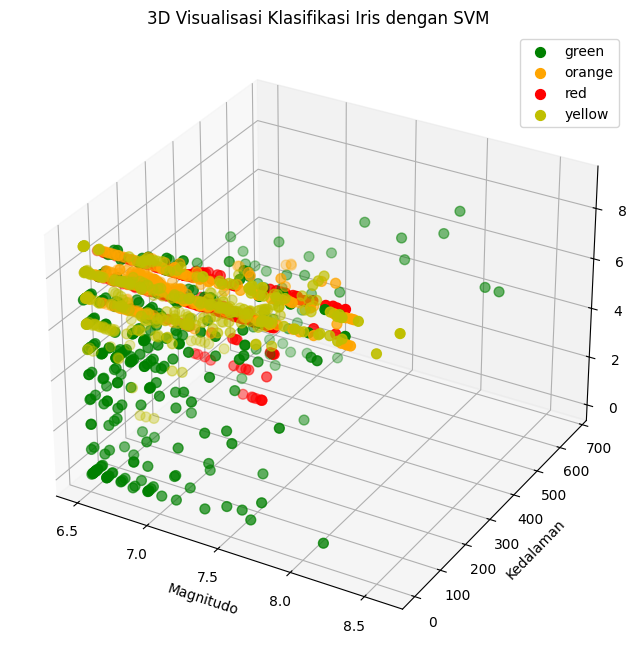

In [115]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from mpl_toolkits.mplot3d import Axes3D

le = LabelEncoder()
df['alertEncoded'] = le.fit_transform(df['alert'])


fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

colors = ['g', 'orange', 'r', 'y']
labels = le.classes_

for i, alert in enumerate(labels):
    subset = df[df['alertEncoded'] == i]
    ax.scatter(
        subset['magnitude'],
        subset['depth'],
        subset['cdi'],
        color=colors[i],
        label=alert,
        s=50
    )

ax.set_title('3D Visualisasi Klasifikasi Iris dengan SVM')
ax.set_xlabel('Magnitudo')
ax.set_ylabel('Kedalaman')
ax.set_zlabel('Skala Guncangan')
ax.legend()
plt.show()